In [25]:
import pandas as pd

df_links = pd.read_csv('links.csv', index_col='Node')
df_links.head()

,Node0,Node1,Node2,Node3,Node4,Node5,Node6,Node7,Node8,Node9,Node10,Node11,Node12,Node13,Node14,Node15,Node16,Node17,Node18,Node19
Node,,,,,,,,,,,,,,,,,,,,
Node0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
Node1,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1,0,0,0
Node2,0,0,0,0,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0
Node3,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0
Node4,0,0,1,0,0,0,0,1,1,0,1,0,0,0,0,1,0,0,0,0


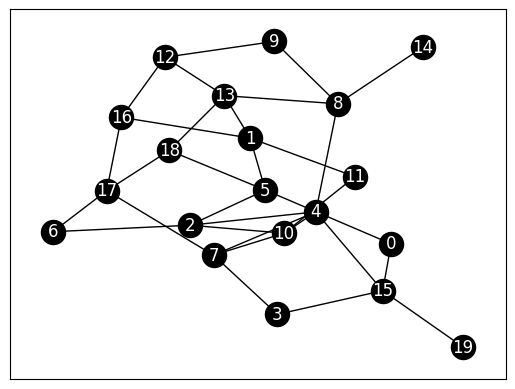

In [26]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

NUM = len(df_links.index)
for i in range(NUM):
    node_no = df_links.columns[i].strip('Node')
    G.add_node(str(node_no))

for i in range(NUM):
    for j in range(NUM):
        node_name = 'Node' + str(j)
        if df_links[node_name].iloc[i] == 1:
            G.add_edge(str(i), str(j))

nx.draw_networkx(G, node_color='k', edge_color='k', font_color='w')
plt.show()

In [27]:
import numpy as np

def determine_link(percent):
    rand_val = np.random.rand()
    if rand_val <= percent:
        return 1
    else:
        return 0

In [28]:
def simulate_percolocation(num, list_active, percent_percolocation):
    for i in range(num):
        if list_active[i] == 1:
            for j in range(num):
                node_name = 'Node' + str(j)
                if df_links[node_name].iloc[i] == 1:
                    if determine_link(percent_percolocation) == 1:
                        list_active[j] = 1
    return list_active

In [29]:
percent_percolocation = 0.1
T_NUM = 36
NUM = len(df_links.index)
list_active = np.zeros(NUM)
list_active[0] = 1

list_timeSeries = []
for t in range(T_NUM):
    list_active = simulate_percolocation(NUM, list_active, percent_percolocation)
    list_timeSeries.append(list_active.copy())

In [30]:
def active_node_coloring(list_active):
    list_color = []
    for i in range(len(list_active)):
        if list_timeSeries[t][i] == 1:
            list_color.append('r')
        else:
            list_color.append('k')
    return list_color

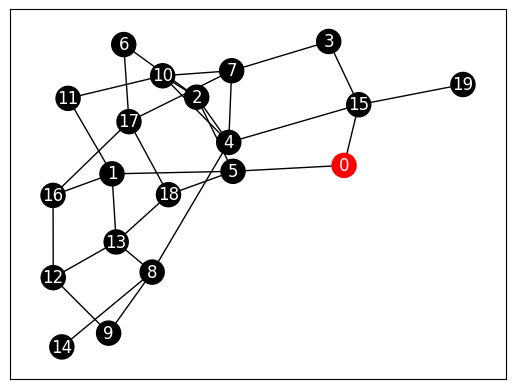

In [31]:
t = 0
nx.draw_networkx(G, font_color='w', node_color=active_node_coloring(list_timeSeries[t]))
plt.show()

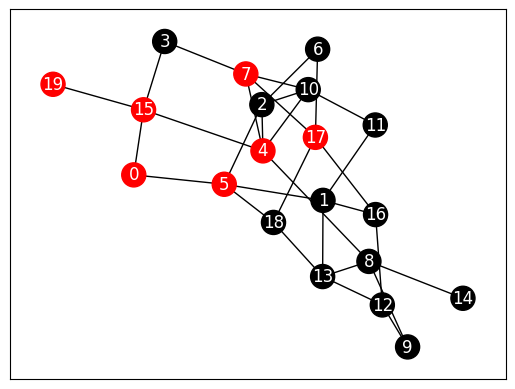

In [32]:
t = 11
nx.draw_networkx(G, font_color='w', node_color=active_node_coloring(list_timeSeries[t]))
plt.show()

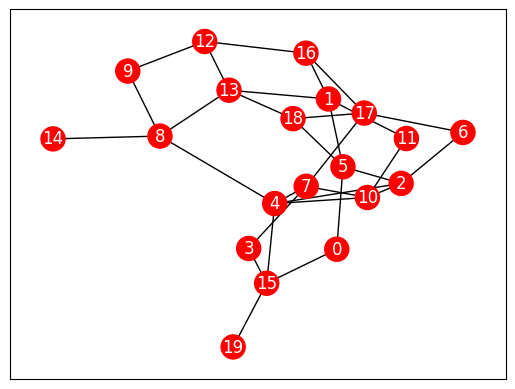

In [33]:
t = 35
nx.draw_networkx(G, font_color='w', node_color=active_node_coloring(list_timeSeries[t]))
plt.show()

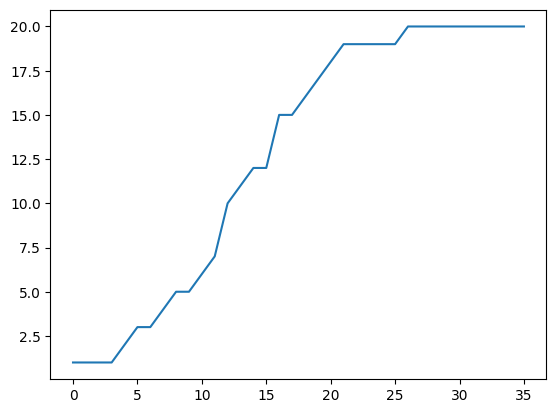

In [34]:
list_timeSeries_num = []
for i in range(len(list_timeSeries)):
    list_timeSeries_num.append(sum(list_timeSeries[i]))

plt.plot(list_timeSeries_num)
plt.show()

In [35]:
def simulate_population(num, list_active, percent_percolocation, percent_disapperence, df_links):

    for i in range(num):
        if list_active[i] == 1:
            for j in range(num):
                node_name = 'Node' + str(j)
                if df_links[node_name].iloc[i] == 1:
                    if determine_link(percent_percolocation) == 1:
                        list_active[j] = 1
    
    for i in range(num):
        if determine_link(percent_disapperence) == 1:
            list_active[i] = 0
    
    return list_active

In [36]:
percent_percolocation = 0.1
percent_disapperence = 0.05
T_NUM = 100
NUM = len(df_links.index)
list_active = np.zeros(NUM)
list_active[0] = 1

list_timeSeries = []
for t in range(T_NUM):
    list_active = simulate_population(NUM, list_active, percent_percolocation, percent_disapperence, df_links)
    list_timeSeries.append(list_active.copy())

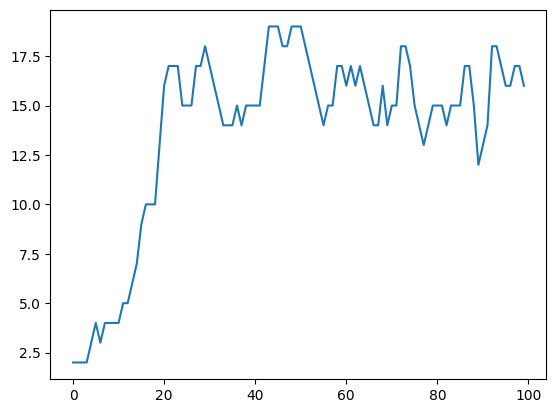

In [37]:
list_timeSeries_num = []
for i in range(len(list_timeSeries)):
    list_timeSeries_num.append(sum(list_timeSeries[i]))

plt.plot(list_timeSeries_num)
plt.show()

In [38]:
percent_percolocation = 0.1
percent_disapperence = 0.2
T_NUM = 100
NUM = len(df_links.index)
list_active = np.zeros(NUM)
list_active[0] = 1

list_timeSeries = []
for t in range(T_NUM):
    list_active = simulate_population(NUM, list_active, percent_percolocation, percent_disapperence, df_links)
    list_timeSeries.append(list_active.copy())

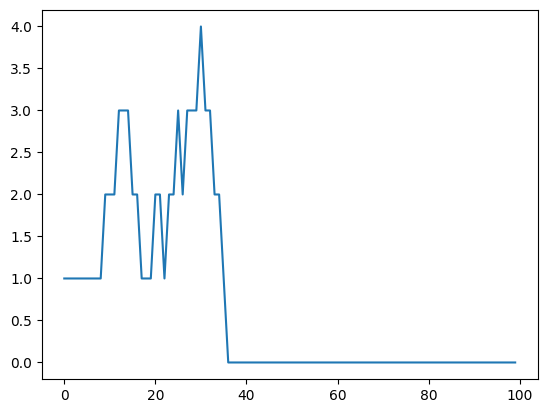

In [39]:
list_timeSeries_num = []
for i in range(len(list_timeSeries)):
    list_timeSeries_num.append(sum(list_timeSeries[i]))

plt.plot(list_timeSeries_num)
plt.show()

In [40]:
print('相図計算開始')
T_NUM = 100
NUM_PhaseDiagram = 20
phaseDiagram = np.zeros((NUM_PhaseDiagram, NUM_PhaseDiagram))
for i_p in range(NUM_PhaseDiagram):
    for i_d in range(NUM_PhaseDiagram):
        percent_percolocation = 0.05 * i_p
        percent_disappercence = 0.05 * i_d
        list_active = np.zeros(NUM)
        list_active[0] = 1

        for t in range(T_NUM):
            list_active = simulate_population(NUM, list_active, percent_percolocation, percent_disapperence, df_links)
        phaseDiagram[i_p][i_d] = sum(list_active)
print(phaseDiagram)

相図計算開始
[[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.]
 [ 0.  5.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   5.  0.]
 [ 0.  0.  0.  7.  0.  9. 12.  0.  0.  0. 11.  0.  0.  0.  0.  0.  7.  0.
  12.  3.]
 [ 0.  0.  9.  0. 16. 13.  0.  0.  7. 10.  0.  0.  0. 10.  0. 12.  0.  0.
   0. 12.]
 [ 0. 11.  0. 11. 14.  0. 13.  0. 13. 12.  0. 15.  9. 14. 11.  9.  0. 15.
  10. 14.]
 [ 0. 13. 18. 14. 14.  0. 15. 15.  0. 17. 16. 14. 13. 14.  9.  0. 15.  0.
  14. 15.]
 [14. 13. 13.  0. 14. 15. 17.  0. 13. 12. 16.  0. 12. 15. 12. 18. 18. 12.
  14. 14.]
 [12. 16. 15.  0. 17. 13. 19. 11. 19. 16. 14. 15. 14. 16. 15. 11. 11. 14.
  11. 12.]
 [15. 15. 15. 11.  0. 16. 16. 18. 14. 14. 15. 17. 17. 17. 14.  0. 10. 11.
  14. 16.]
 [16. 17. 17. 16. 15. 12. 16. 16. 16. 13. 16. 15. 15. 13. 16. 19. 13. 15.
  17. 16.]
 [19. 18. 15. 16. 14. 17. 13. 13. 11. 17. 16. 15. 16. 17. 

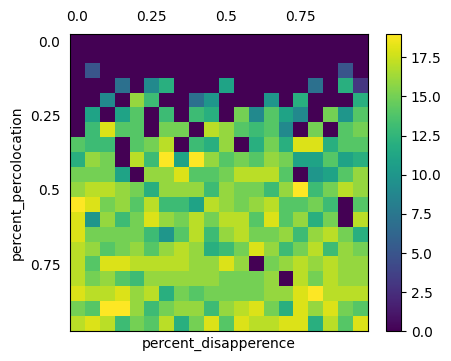

In [41]:
plt.matshow(phaseDiagram)
plt.colorbar(shrink=0.8)
plt.xlabel('percent_disapperence')
plt.ylabel('percent_percolocation')
plt.xticks(np.arange(0.0, 20.0, 5), np.arange(0.0, 1.0, 0.25))
plt.yticks(np.arange(0.0, 20.0, 5), np.arange(0.0, 1.0, 0.25))
plt.tick_params(bottom=False, left=False, right=False, top=False)
plt.show()

In [42]:
df_mem_links = pd.read_csv('links_members.csv', index_col='Node')
df_mem_links.head()

,Node0,Node1,Node2,Node3,Node4,Node5,Node6,Node7,Node8,Node9,...,Node530,Node531,Node532,Node533,Node534,Node535,Node536,Node537,Node538,Node539
Node,,,,,,,,,,,,,,,,,,,,,
Node0,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Node1,0,0,0,0,1,1,0,0,0,0,...,0,1,1,0,0,0,0,0,0,0
Node2,1,0,0,0,0,1,0,1,0,0,...,0,0,1,0,1,0,0,1,1,0
Node3,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Node4,0,1,0,0,0,1,0,0,0,0,...,0,0,0,1,1,0,0,0,1,0


In [47]:
df_mem_info = pd.read_csv('info_members.csv', index_col='Node')
df_mem_info

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Node,,,,,,,,,,,,,,,,,,,,,
Node0,1,1,1,1,1,1,1,0,0,0,...,1,1,1,1,1,1,1,0,0,0
Node1,0,0,0,0,0,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
Node2,0,0,0,0,0,0,1,1,1,1,...,1,1,1,1,0,1,1,1,1,1
Node3,0,0,0,0,0,1,1,1,1,1,...,1,1,1,1,1,0,1,1,1,0
Node4,0,0,0,0,0,0,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Node535,0,0,0,0,0,0,0,1,1,1,...,1,1,1,1,1,1,1,1,1,1
Node536,0,0,0,0,0,1,1,1,1,1,...,1,1,1,1,1,1,1,0,1,1
Node537,0,0,0,0,0,0,0,0,1,0,...,1,1,1,0,1,1,1,1,1,0


In [44]:
NUM = len(df_mem_links.index)
array_linkNum = np.zeros(NUM)
for i in range(NUM):
    array_linkNum[i] = sum(df_mem_links['Node' + str(i)])

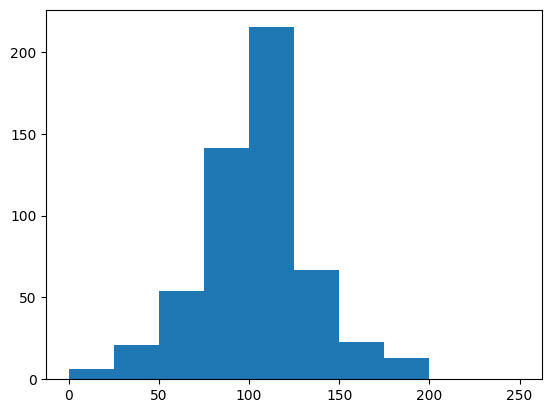

In [45]:
plt.hist(array_linkNum, bins=10, range=(0, 250))
plt.show()

In [49]:
NUM = len(df_mem_info.index)
T_NUM = len(df_mem_info.columns) - 1

count_active = 0
count_active_to_inactive = 0
for t in range(T_NUM):
    for i in range(NUM):
        if (df_mem_info.iloc[i][t] == 1):
            count_active_to_inactive += 1
            if (df_mem_info.iloc[i][t+1] == 0):
                count_active += 1
estimated_percent_disapperence = count_active / count_active_to_inactive

/tmp/ipykernel_29587/3509662297.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if (df_mem_info.iloc[i][t] == 1):
/tmp/ipykernel_29587/3509662297.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if (df_mem_info.iloc[i][t+1] == 0):


In [ ]:
count_link = 0
count_link_to_active = 0
count_link_temp = 0
for t in range(T_NUM):
    df_link_t = df_mem_info[df_mem_info[str(t)] == 1]
    temp_flag_count = np.zeros(NUM)
    for i in range(len(df_link_t.index)):
        index_i = int(df_link_t.index[i].replace('Node', ''))
        df_link_temp = df_mem_links[df_mem_links['Node' + str(index_i)] == 1]
        for j in range(len(df_link_temp.index)):
            index_j = int(df_link_temp.index[j].replace('Node', ''))
            if (df_mem_info.iloc[index_j][t] == 0):
                if (temp_flag_count[index_j] == 0):
                    count_link += 1
                if (df_mem_info.iloc[index_j][t+1] == 1):
                    if (temp_flag_count[index_j] == 0):
                        temp_flag_count[index_j] = 1
                        count_link_to_active += 1
estimated_percent_percolation = count_link_to_active / count_link

/tmp/ipykernel_29587/2152077469.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if (df_mem_info.iloc[index_j][t] == 0):
/tmp/ipykernel_29587/2152077469.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if (df_mem_info.iloc[index_j][t+1] == 1):


In [51]:
estimated_percent_disapperence

0.10147163541419416

In [52]:
estimated_percent_percolation

0.039006364196263604

In [53]:
percent_percolation = estimated_percent_percolation
percent_disapperence = estimated_percent_disapperence
T_NUM = 24
NUM = len(df_mem_links.index)
list_active = np.zeros(NUM)
list_active[0] = 1
list_timeSeries = []
for t in range(T_NUM):
    list_active = simulate_population(NUM, list_active, percent_percolation, percent_disapperence, df_mem_links)
    list_timeSeries.append(list_active.copy())

In [54]:
list_timeSeries_num = []
for i in range(len(list_timeSeries)):
    list_timeSeries_num.append(sum(list_timeSeries[i]))

In [56]:
T_NUM = len(df_mem_info.columns) - 1
list_timeSeries_num_real = []
for t in range(0, T_NUM):
    list_timeSeries_num_real.append(len(df_mem_info[df_mem_info[str(t)] == 1].index))

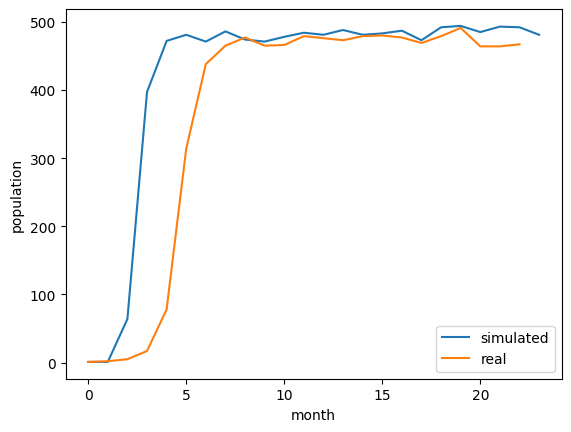

In [57]:
plt.plot(list_timeSeries_num, label='simulated')
plt.plot(list_timeSeries_num_real, label='real')
plt.xlabel('month')
plt.ylabel('population')
plt.legend(loc='lower right')
plt.show()